# CRISP-DM Assignment

##Data Understanding

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       ------------

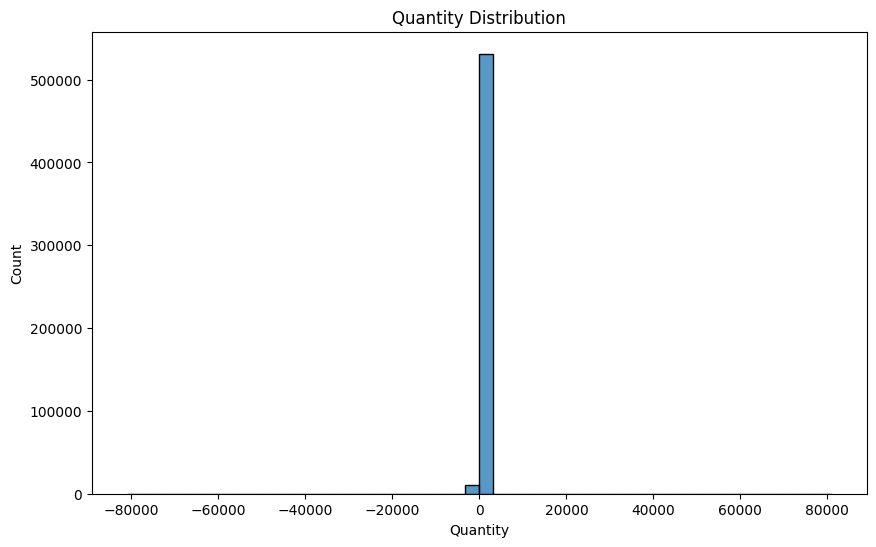

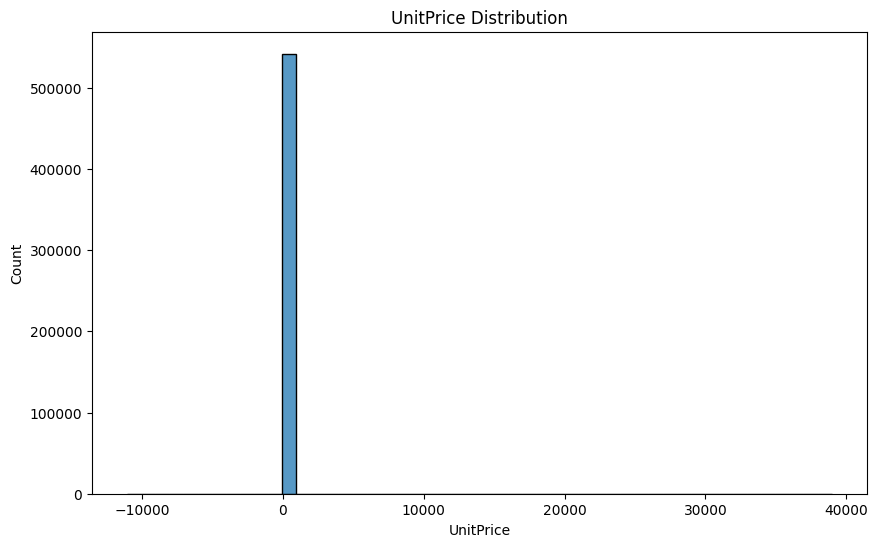

In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/kaggle/online_retail.csv', encoding='ISO-8859-1')

# Display the first few rows of the dataset
print(data.head())

# Check for missing values and data types
print(data.info())

# Basic statistics of numerical columns
print(data.describe())

# Unique values in columns
print(data.nunique())

# Explore distribution of Quantity and UnitPrice
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(data['Quantity'], kde=False, bins=50)
plt.title('Quantity Distribution')
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(data['UnitPrice'], kde=False, bins=50)
plt.title('UnitPrice Distribution')
plt.show()


##Data Preparation

In [ ]:
# Drop rows with missing CustomerID
data_clean = data.dropna(subset=['CustomerID'])

# Remove negative or zero quantity values
data_clean = data_clean[data_clean['Quantity'] > 0]

# Remove rows with negative or zero UnitPrice
data_clean = data_clean[data_clean['UnitPrice'] > 0]

# Create a new feature for total transaction value
data_clean['TotalPrice'] = data_clean['Quantity'] * data_clean['UnitPrice']

# Convert InvoiceDate to datetime
data_clean['InvoiceDate'] = pd.to_datetime(data_clean['InvoiceDate'])

# Filter data to consider only relevant time frame (optional)
data_clean = data_clean[(data_clean['InvoiceDate'] >= '2010-12-01') & (data_clean['InvoiceDate'] < '2011-12-01')]

print(data_clean.info())


<ipython-input-4-2f72889948e6>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['TotalPrice'] = data_clean['Quantity'] * data_clean['UnitPrice']
<ipython-input-4-2f72889948e6>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['InvoiceDate'] = pd.to_datetime(data_clean['InvoiceDate'])


<class 'pandas.core.frame.DataFrame'>
Index: 380580 entries, 0 to 516368
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    380580 non-null  object        
 1   StockCode    380580 non-null  object        
 2   Description  380580 non-null  object        
 3   Quantity     380580 non-null  int64         
 4   InvoiceDate  380580 non-null  datetime64[ns]
 5   UnitPrice    380580 non-null  float64       
 6   CustomerID   380580 non-null  float64       
 7   Country      380580 non-null  object        
 8   TotalPrice   380580 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 29.0+ MB
None


##Modeling

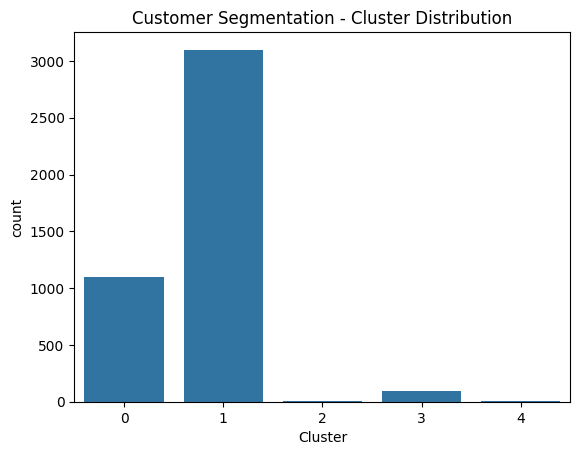

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Create RFM (Recency, Frequency, Monetary) features for segmentation
rfm_data = data_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (data_clean['InvoiceDate'].max() - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalPrice': 'Monetary'})

# Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
rfm_data['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Visualize cluster distribution
sns.countplot(x='Cluster', data=rfm_data)
plt.title('Customer Segmentation - Cluster Distribution')
plt.show()


## Filtering

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Create a pivot table for user-item matrix
pivot_table = data_clean.pivot_table(index='CustomerID', columns='StockCode', values='TotalPrice', aggfunc='sum').fillna(0)

# Compute similarity matrix
similarity_matrix = cosine_similarity(pivot_table)

# Get recommendations for a sample customer
customer_idx = 0  # Index for CustomerID
similar_customers = similarity_matrix[customer_idx].argsort()[::-1][:5]

print(f"Top 5 similar customers to customer {customer_idx}: {similar_customers}")


Top 5 similar customers to customer 0: [   0 2340 3396 3587 2368]


## Evaluation

In [ ]:
from sklearn.metrics import silhouette_score

# Silhouette score for KMeans clustering
silhouette_avg = silhouette_score(rfm_scaled, rfm_data['Cluster'])
print(f'Silhouette Score for customer segmentation: {silhouette_avg}')


Silhouette Score for customer segmentation: 0.6150399020389157
